In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [7]:
data = pd.read_csv('DS-4002-sp26-survey-results.csv')

In [10]:
data.columns

Index(['Timestamp', 'Are you a full-time undergraduate UVA student?',
       'What year are you?', 'Do you believe a hotdog is a sandwich?'],
      dtype='object')

In [9]:
data.isna().sum()

Timestamp                                         0
Are you a full-time undergraduate UVA student?    0
What year are you?                                0
Do you believe a hotdog is a sandwich?            0
dtype: int64

In [ ]:
print(data.head())
print("\nData shape:", data.shape)
print("\nData types:")
print(data.dtypes)

            Timestamp Are you a full-time undergraduate UVA student?  \
0  1/14/2026 14:54:44                                            Yes   
1  1/14/2026 14:55:14                                            Yes   
2  1/14/2026 14:56:49                                            Yes   
3  1/14/2026 14:58:15                                            Yes   
4  1/14/2026 14:58:25                                            Yes   

  What year are you? Do you believe a hotdog is a sandwich?  
0                3rd                                     No  
1                4th                                     No  
2                4th                                     No  
3                4th                                    Yes  
4                4th                                    Yes  

Data shape: (79, 4)

Data types:
Timestamp                                         object
Are you a full-time undergraduate UVA student?    object
What year are you?                             

In [14]:
data.drop(data[data['Are you a full-time undergraduate UVA student?'] == 'No'].index, inplace=True)

In [15]:
data.shape

(76, 4)

## Potential Bias Analysis

### 1. **Selection Bias**
- Survey conducted on UVA students only - may not represent broader population
- Self-selection: people with strong opinions about hot dogs more likely to respond

### 2. **Response Bias**
- Leading questions could bias responses toward particular answers
- Social desirability bias: respondents may answer based on perceived "correct" opinion
- Potential for joke/satirical responses given the seemingly trivial topic

### 3. **Coverage Bias**
- Limited to UVA community (academic, affluent, younger demographic)
- Geographic bias: Virginia/Southeast preferences not representative nationally
- Socioeconomic status likely skewed toward college-educated, middle+ income

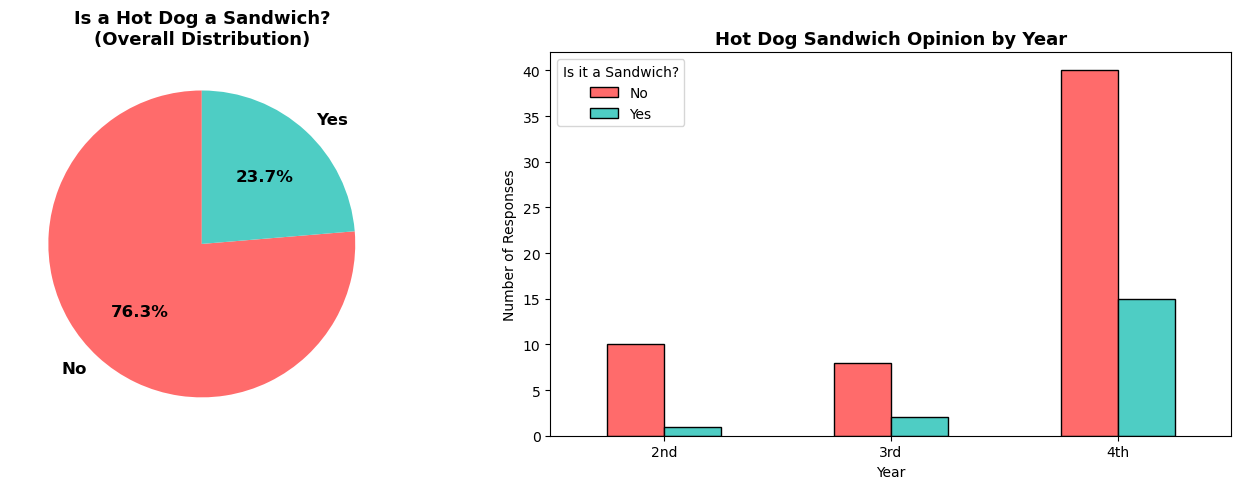


CHI-SQUARED TESTS FOR INDEPENDENCE

1. Class Year vs. Hot Dog Sandwich Opinion
------------------------------------------------------------
Chi-squared statistic: 1.7630
P-value: 0.4142
Degrees of freedom: 2
Result: NO significant association (p >= 0.05)

2. Full-time Student Status vs. Hot Dog Sandwich Opinion
------------------------------------------------------------
Chi-squared statistic: 0.0000
P-value: 1.0000
Degrees of freedom: 0
Result: NO significant association (p >= 0.05)

SURVEY SUMMARY STATISTICS

Total Responses: 76

--- Hot Dog is a Sandwich? ---
Yes: 18 (23.7%)
No: 58 (76.3%)

--- Breakdown by Year ---
2nd Year: 11 responses (1 think it's a sandwich - 9.1%)
3rd Year: 10 responses (2 think it's a sandwich - 20.0%)
4th Year: 55 responses (15 think it's a sandwich - 27.3%)


In [21]:
# Survey Results Analysis

# 1. Main Question: Is a hot dog a sandwich?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall distribution - Hot dog is sandwich
sandwich_counts = data['Do you believe a hotdog is a sandwich?'].value_counts()
colors_sandwich = ['#ff6b6b', '#4ecdc4']
axes[0].pie(sandwich_counts.values, labels=sandwich_counts.index, autopct='%1.1f%%', 
            colors=colors_sandwich, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Is a Hot Dog a Sandwich?\n(Overall Distribution)', fontsize=13, weight='bold')

# Plot 2: Hot dog opinion by year
year_sandwich = pd.crosstab(data['What year are you?'], data['Do you believe a hotdog is a sandwich?'])
year_sandwich.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[1].set_title('Hot Dog Sandwich Opinion by Year', fontsize=13, weight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Responses')
axes[1].legend(title='Is it a Sandwich?', labels=['No', 'Yes'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Chi-Squared Tests
print("\n" + "="*60)
print("CHI-SQUARED TESTS FOR INDEPENDENCE")
print("="*60)

# Test 1: Year vs. Hot dog sandwich opinion
print("\n1. Class Year vs. Hot Dog Sandwich Opinion")
print("-" * 60)
chi2_year, p_year, dof_year, expected_year = chi2_contingency(year_sandwich)
print(f"Chi-squared statistic: {chi2_year:.4f}")
print(f"P-value: {p_year:.4f}")
print(f"Degrees of freedom: {dof_year}")
if p_year < 0.05:
    print("Result: SIGNIFICANT association (p < 0.05)")
else:
    print("Result: NO significant association (p >= 0.05)")

# Test 2: Student status vs. Hot dog sandwich opinion
print("\n2. Full-time Student Status vs. Hot Dog Sandwich Opinion")
print("-" * 60)
student_sandwich = pd.crosstab(data['Are you a full-time undergraduate UVA student?'], 
                                data['Do you believe a hotdog is a sandwich?'])
chi2_student, p_student, dof_student, expected_student = chi2_contingency(student_sandwich)
print(f"Chi-squared statistic: {chi2_student:.4f}")
print(f"P-value: {p_student:.4f}")
print(f"Degrees of freedom: {dof_student}")
if p_student < 0.05:
    print("Result: SIGNIFICANT association (p < 0.05)")
else:
    print("Result: NO significant association (p >= 0.05)")

# Summary statistics
print("\n" + "="*60)
print("SURVEY SUMMARY STATISTICS")
print("="*60)
print(f"\nTotal Responses: {len(data)}")

print(f"\n--- Hot Dog is a Sandwich? ---")
print(f"Yes: {(data['Do you believe a hotdog is a sandwich?'] == 'Yes').sum()} ({(data['Do you believe a hotdog is a sandwich?'] == 'Yes').sum()/len(data)*100:.1f}%)")
print(f"No: {(data['Do you believe a hotdog is a sandwich?'] == 'No').sum()} ({(data['Do you believe a hotdog is a sandwich?'] == 'No').sum()/len(data)*100:.1f}%)")

print(f"\n--- Breakdown by Year ---")
for year in sorted(data['What year are you?'].unique()):
    count = len(data[data['What year are you?'] == year])
    yes_count = len(data[(data['What year are you?'] == year) & (data['Do you believe a hotdog is a sandwich?'] == 'Yes')])
    print(f"{year} Year: {count} responses ({yes_count} think it's a sandwich - {yes_count/count*100:.1f}%)")